# Pro Graph: GCN vs. GAT for Protein-Protein Interaction Prediction

This notebook explores the Yeast PPI network (SEAL benchmark), trains GCN and GAT models for link prediction, and compares results using a multi-seed evaluation for statistical honesty.

In [1]:
import sys
sys.path.insert(0, '../src')

import networkx as nx
import matplotlib.pyplot as plt
import scipy.io as sio

from data.loader import load_yeast_graph_structural, split_graph_for_link_prediction

## Dataset overview

Yeast protein-protein interaction network from Zhang & Chen (NeurIPS 2018), originally sourced from the DIP database (von Mering et al., 2002). Note: this benchmark distribution is fully anonymized -- no protein identifiers (UniProt IDs, gene names) survive, so biologically informed embeddings (e.g. ProtBERT) cannot be legitimately attached to specific nodes here. We use structural graph features instead.

In [2]:
data = load_yeast_graph_structural()
print(data)
print()
print(f"Nodes (proteins): {data.num_nodes}")
print(f"Edges (interactions, undirected): {data.edge_index.shape[1] // 2}")
print(f"Node feature dimensions: {data.x.shape[1]} (degree, clustering, PageRank, betweenness)")

Data(x=[2375, 4], edge_index=[2, 23386], num_nodes=2375)

Nodes (proteins): 2375
Edges (interactions, undirected): 11693
Node feature dimensions: 4 (degree, clustering, PageRank, betweenness)


## Visualize a local neighborhood

The full graph is too dense to visualize cleanly, so we sample the neighborhood around the highest-degree protein.

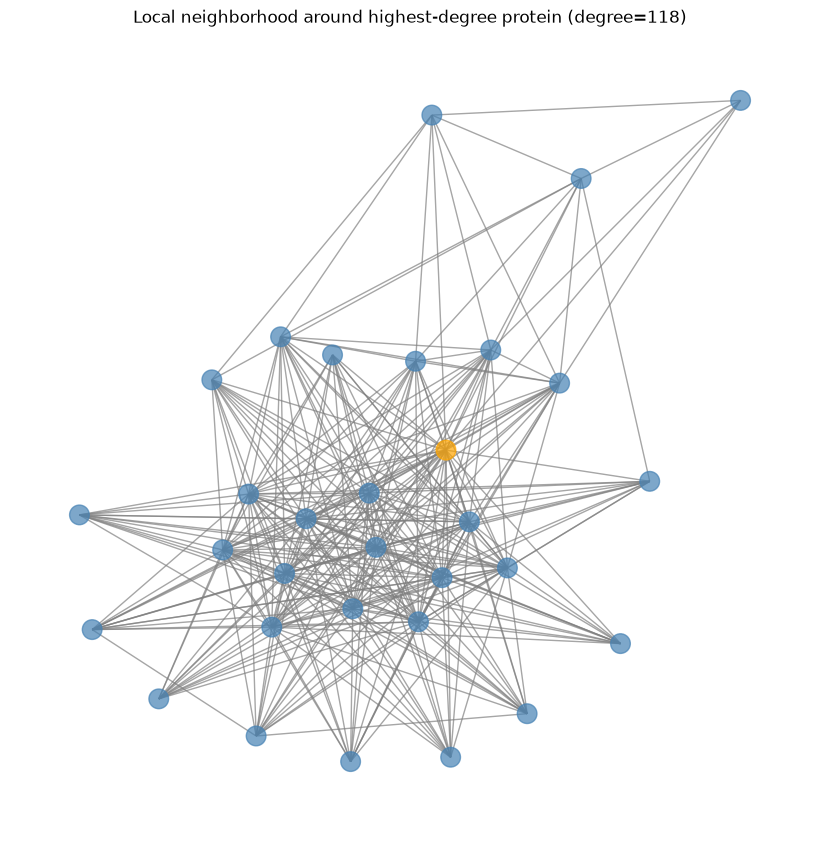

In [3]:
mat = sio.loadmat('../data/raw/yeast.mat')
adjacency = mat['net']
G = nx.from_scipy_sparse_array(adjacency)

degrees = dict(G.degree())
hub_node = max(degrees, key=degrees.get)
neighbors = list(G.neighbors(hub_node))[:30]
subgraph_nodes = [hub_node] + neighbors
subG = G.subgraph(subgraph_nodes)

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(subG, seed=42)
node_colors = ['orange' if n == hub_node else 'steelblue' for n in subG.nodes()]
nx.draw(subG, pos, node_color=node_colors, node_size=200, with_labels=False, edge_color='gray', alpha=0.7)
plt.title(f'Local neighborhood around highest-degree protein (degree={degrees[hub_node]})')
plt.show()

## Train/val/test split for link prediction

In [4]:
train_data, val_data, test_data = split_graph_for_link_prediction(data, seed=42)

print(f"Train supervision edges: {train_data.edge_label_index.size(1)}")
print(f"Val edges (pos+neg): {val_data.edge_label_index.size(1)}")
print(f"Test edges (pos+neg): {test_data.edge_label_index.size(1)}")

Train supervision edges: 9940
Val edges (pos+neg): 1168
Test edges (pos+neg): 2338


## Multi-seed results

Initial single-run comparisons between GCN and GAT gave contradictory results across different runs, due to non-deterministic negative sampling and dropout. To get a statistically honest comparison, both models were trained across 5 seeds (see `scripts/run_multi_seed.py`) and we report mean +/- standard deviation rather than any single run.

In [5]:
import pandas as pd

# Results from scripts/run_multi_seed.py (5 seeds: 42-46)
gcn_runs = [0.9184, 0.9037, 0.9176, 0.9233, 0.9029]
gat_runs = [0.9164, 0.9141, 0.9143, 0.9134, 0.9071]

results = pd.DataFrame({
    'Model': ['GCN'] * 5 + ['GAT'] * 5,
    'Seed': [42, 43, 44, 45, 46] * 2,
    'Test AUC': gcn_runs + gat_runs,
})
summary = results.groupby('Model')['Test AUC'].agg(['mean', 'std'])
summary

,mean,std
Model,,
GAT,0.91306,0.003515
GCN,0.91318,0.009284


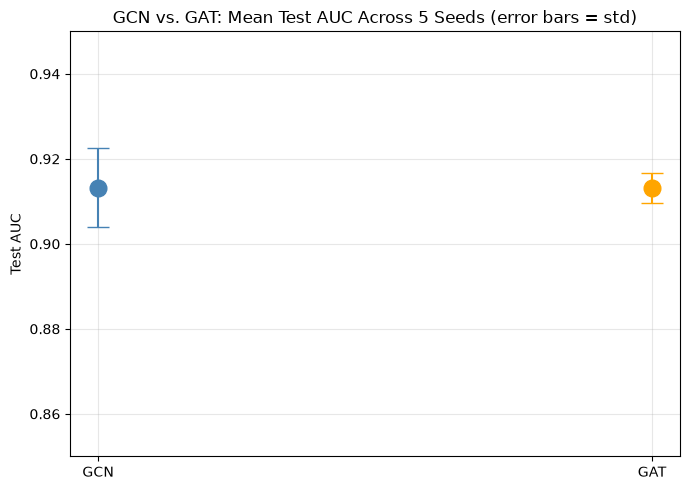

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(['GCN'], [summary.loc['GCN', 'mean']], yerr=[summary.loc['GCN', 'std']],
            fmt='o', markersize=12, capsize=8, color='steelblue', label='GCN')
ax.errorbar(['GAT'], [summary.loc['GAT', 'mean']], yerr=[summary.loc['GAT', 'std']],
            fmt='o', markersize=12, capsize=8, color='orange', label='GAT')
ax.set_ylabel('Test AUC')
ax.set_title('GCN vs. GAT: Mean Test AUC Across 5 Seeds (error bars = std)')
ax.set_ylim(0.85, 0.95)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Key Findings

1. **GCN and GAT perform essentially identically on this graph** (mean test AUC: GCN 0.9132, GAT 0.9131 -- a difference of 0.0001, well within noise). Earlier single-run comparisons had suggested first GAT, then GCN was ahead; neither claim survived a proper multi-seed evaluation.

2. **GAT is meaningfully more consistent** (std 0.0031 vs. GCN's 0.0083 -- roughly 2.7x lower variance), even without an accuracy advantage. This is a real, if modest, practical benefit: more predictable behavior across different random initializations.

3. **Methodological lesson**: single-run comparisons between stochastic models can be actively misleading. Negative sampling and dropout both introduce randomness; only a multi-seed comparison (mean +/- std) gives a trustworthy picture.

4. **Known limitation**: this benchmark dataset is fully anonymized (no protein identifiers survive in the public SEAL distribution), so biologically-informed embeddings (e.g. ProtBERT) could not legitimately be attached to specific nodes. A protein-ID-linked dataset (e.g. from STRING) would be required to test that direction -- noted as future work.